In [1]:
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
marker_ref = analysis_run["markers"]

ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_percentMito', 
            'RNA_percentRibo', 'RNA_leiden_cluster', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_clusters', 
            'clusters_coarse', 'RNA_UMAP2', 'RNA_UMAP1', 'S_score', 'clusters', 
          
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'highly_variable_genes', 'nCells', 
            'dropOuts'

In [3]:
cluster_values = analysis_run.cells.fetch("clusters")
pd.Series(cluster_values).value_counts().sort_index()

1     369
2     563
3     496
4     197
5     218
6     346
7     148
8      95
9     495
10    320
11    204
12    245
Name: count, dtype: int64

In [4]:
ds.show_zarr_tree(depth=1)

/
├── RNA
│   ├── artifacts
│   ├── counts (3696, 27998) uint16
│   ├── countsT (27998, 3696) uint16
│   └── featureData
├── artifacts
│   ├── cell_selection
│   └── metadata_snapshot
├── cellData
│   ├── G2M_score (3696,) float32
│   ├── I (3696,) bool
│   ├── RNA_UMAP1 (3696,) float32
│   ├── RNA_UMAP2 (3696,) float32
│   ├── RNA_clusters (3696,) int64
│   ├── RNA_leiden_cluster (3696,) int64
│   ├── RNA_nCounts (3696,) float64
│   ├── RNA_nFeatures (3696,) float64
│   ├── RNA_percentMito (3696,) float64
│   ├── RNA_percentRibo (3696,) float64
│   ├── S_score (3696,) float32
│   ├── clusters (3696,) <U13
│   ├── clusters_coarse (3696,) <U13
│   ├── ids (3696,) <U16
│   └── names (3696,) <U16
└── pipeline
    └── runs



In [5]:
ds.show_zarr_tree(start="cellData")

/cellData
├── G2M_score (3696,) float32
├── I (3696,) bool
├── RNA_UMAP1 (3696,) float32
├── RNA_UMAP2 (3696,) float32
├── RNA_clusters (3696,) int64
├── RNA_leiden_cluster (3696,) int64
├── RNA_nCounts (3696,) float64
├── RNA_nFeatures (3696,) float64
├── RNA_percentMito (3696,) float64
├── RNA_percentRibo (3696,) float64
├── S_score (3696,) float32
├── clusters (3696,) <U13
├── clusters_coarse (3696,) <U13
├── ids (3696,) <U16
└── names (3696,) <U16

  RNA_percentMito: shape=(3696,), dtype=float64, chunks=(100000,)
  G2M_score: shape=(3696,), dtype=float32, chunks=(100000,)
  names: shape=(3696,), dtype=<U16, chunks=(100000,)
  RNA_nCounts: shape=(3696,), dtype=float64, chunks=(100000,)
  I: shape=(3696,), dtype=bool, chunks=(100000,)
  RNA_UMAP2: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_nFeatures: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_clusters: shape=(3696,), dtype=int64, chunks=(100000,)
  RNA_percentRibo: shape=(3696,), dtype=float64, chunks=(100000,)
  

In [6]:
ds.cells.to_pandas_dataframe(["I"])["I"].value_counts()

I
True    3696
Name: count, dtype: int64

In [7]:
ds.show_zarr_tree(start="RNA", depth=1)

/RNA
├── artifacts
│   ├── ann_index
│   ├── cluster_labels
│   ├── cluster_selection
│   ├── connectivity_map
│   ├── embedding
│   ├── embedding_initialization
│   ├── feature_scaling
│   ├── feature_selection
│   ├── feature_summary
│   ├── marker_table
│   ├── metadata_snapshot
│   ├── neighbors
│   ├── normalized
│   └── reduction
├── counts (3696, 27998) uint16
├── countsT (27998, 3696) uint16
└── featureData
    ├── I (27998,) bool
    ├── dropOuts (27998,) int64
    ├── highly_variable_genes (27998,) <U5
    ├── ids (27998,) <U15
    ├── nCells (27998,) int64
    └── names (27998,) <U15

  countsT: shape=(27998, 3696), dtype=uint16, chunks=(27056, 1848), shards=(27056, 3696)
  counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13528), shards=(3696, 40584)


In [8]:
ds.show_zarr_tree(start="RNA/featureData", depth=1)

/RNA/featureData
├── I (27998,) bool
├── dropOuts (27998,) int64
├── highly_variable_genes (27998,) <U5
├── ids (27998,) <U15
├── nCells (27998,) int64
└── names (27998,) <U15

  nCells: shape=(27998,), dtype=int64, chunks=(100000,)
  I: shape=(27998,), dtype=bool, chunks=(100000,)
  names: shape=(27998,), dtype=<U15, chunks=(100000,)
  highly_variable_genes: shape=(27998,), dtype=<U5, chunks=(100000,)
  dropOuts: shape=(27998,), dtype=int64, chunks=(100000,)
  ids: shape=(27998,), dtype=<U15, chunks=(100000,)


In [9]:
ds.show_zarr_tree(start="RNA/artifacts", depth=1)

/RNA/artifacts
├── ann_index
│   └── 6fe9cd15308f1bee8921c831091084f5fa21fec4e937da0c3eeee797048e09d6
├── cluster_labels
│   └── cdf1446cb3957ae5c63aa0769cbe5f9be42740ca6ce23895e9e327f86bece646
├── cluster_selection
│   └── 3883201ef94e0a89dd8143d557bec8038a485714b3c8a898808ce6027df2ff83
├── connectivity_map
│   └── 142b9a52613b437eda8603b08dd1d5a3ffe988cfc7b7073976f81a9c660d0a46
├── embedding
│   └── d47c89bc80a342dd7fc60377d6be11a8f81b2785f5c76e8b2d8030e22f77351b
├── embedding_initialization
│   └── 129b787d9f4506f7860e686d170bb9030ce01de16d4b6eefd3de61291d316f4e
├── feature_scaling
│   └── d6ec76a36f64f4e521f5da4706df2154ba292011af05aefdd885acf80ce3b44e
├── feature_selection
│   ├── b4ce7665e286fac0518aacd9405cb13d14c4b317b11768a2b48e9cb1c8abd7a2
│   └── cd93aaf4a730be72483f86bbcf2324e41632bfe6808c6061af08b9101fc09a0e
├── feature_summary
│   └── 67998d33311fd34c65a507502bfe22e25b00f9324ab775eaa6316bb97b2a70fd
├── marker_table
│   └── b0d390f6d0e7c888437bf3eac52c8b26808d5972ead70f476

In [10]:
ds.cells.head()

,I,ids,names,G2M_score,RNA_percentMito,RNA_percentRibo,clusters_coarse,RNA_clusters,RNA_leiden_cluster,RNA_nFeatures,RNA_nCounts,RNA_UMAP2,RNA_UMAP1,S_score,clusters
0,True,AAACCTGAGAGGGATA,AAACCTGAGAGGGATA,-0.252071,0.706500,15.563181,Pre-endocrine,1,1,2356.0,4954.0,0.658178,-14.955841,-0.224902,Pre-endocrine
1,True,AAACCTGAGCCTTGAT,AAACCTGAGCCTTGAT,-0.232610,1.286947,30.632160,Ductal,2,2,2613.0,7071.0,-4.634864,10.222909,-0.014707,Ductal
2,True,AAACCTGAGGCAATTA,AAACCTGAGGCAATTA,-0.286834,0.687961,19.041769,Endocrine,3,3,1984.0,4070.0,-3.424235,-20.100021,-0.171255,Alpha
3,True,AAACCTGCATCATCCC,AAACCTGCATCATCCC,0.191243,1.195886,28.653432,Ductal,4,4,2860.0,8362.0,-15.258952,11.473139,0.599244,Ductal
4,True,AAACCTGGTAAGTGGC,AAACCTGGTAAGTGGC,-0.126030,1.094310,19.419021,Ngn3 high EP,6,6,2211.0,5026.0,12.557617,-9.147018,-0.179981,Ngn3 high EP


In [11]:
ds.RNA.feats.head()

,I,ids,names,highly_variable_genes,nCells,dropOuts
0,True,Xkr4,Xkr4,False,6,3690
1,True,Gm37381,Gm37381,,0,3696
2,True,Rp1,Rp1,,0,3696
3,True,Rp1-1,Rp1-1,,0,3696
4,True,Sox17,Sox17,,0,3696


In [12]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "RNA_nCounts", "RNA_nFeatures", "clusters"]
).set_index("ids")

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP
...,...,...,...
TTTGTCAAGTGACATA,9219.0,3283.0,Pre-endocrine
TTTGTCAAGTGTGGCA,7298.0,2605.0,Ngn3 high EP
TTTGTCAGTTGTTTGG,5234.0,2168.0,Ductal


In [13]:
first_run_cluster = cluster_values[0]
is_first_cluster = cluster_values == first_run_cluster
ds.cells.insert(
    column_name="is_first_cluster",
    values=is_first_cluster,
    overwrite=True,
)

In [14]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "clusters", "is_first_cluster"]
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


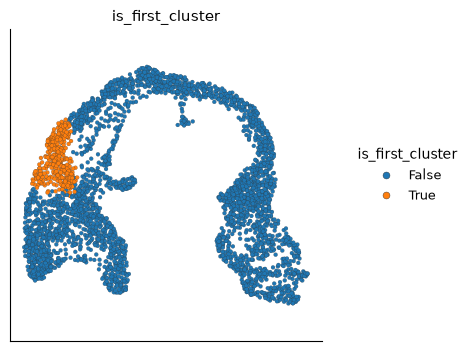

In [15]:
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by="is_first_cluster",
)

In [16]:
print(
    "fetch:", ds.cells.fetch("clusters", key="is_first_cluster").shape,
    "fetch_all:", ds.cells.fetch_all("clusters").shape,
)

fetch: (369,) fetch_all: (3696,)


In [17]:
active_before = int(ds.cells.fetch_all("I").sum())
count_range = ds.cells.sift(
    "RNA_nCounts",
    min_v=1000,
    max_v=15000,
)
joint_range = ds.cells.multi_sift(
    columns=["RNA_nCounts", "RNA_nFeatures"],
    lows=[1000, 500],
    highs=[15000, 4000],
)
ductal_rows = ds.cells.get_index_by(["Ductal"], "clusters")

print(
    "count_range:", int(count_range.sum()),
    "joint_range:", int(joint_range.sum()),
    "ductal_rows:", int(ductal_rows.size),
)
print("Active cells (I) before:", active_before)
print("Active cells (I) after:", int(ds.cells.fetch_all("I").sum()))

count_range: 3669 joint_range: 3667 ductal_rows: 916
Active cells (I) before: 3696
Active cells (I) after: 3696


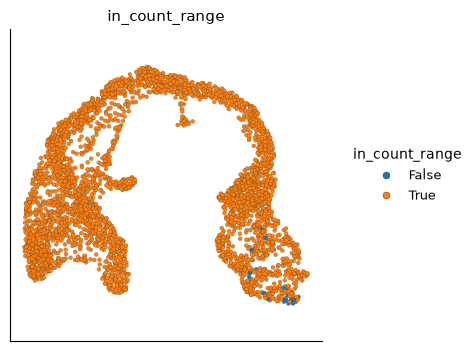

In [18]:
ds.cells.insert(column_name="in_count_range", values=count_range, overwrite=True)
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by="in_count_range",
)

In [19]:
print("Raw shape:", ds.RNA.rawData.shape)
print("Normed shape:", ds.RNA.normed().shape)
ds.RNA.rawData[:3, :5].compute()

Raw shape: (3696, 27998)
Normed shape: (3696, 27998)


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint16)

In [20]:
ds.RNA.normed()[:3, :5].compute()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [21]:
reused_normalized = ds.run_normalization(
    analysis_run["analysis_cell_selection"],
    analysis_run["highly_variable_features"],
)
print("Reused:", reused_normalized == analysis_run["normalized"])
reused_normalized

Reused: True


ArtifactRef(assay='RNA', kind='normalized', artifact_id='41ca0c5b91c9...')

In [22]:
status = ds.inspect_artifact(reused_normalized)
print("Complete:", status.complete)
print("Operation:", status.operation)
print("Parameters:", status.parameters)

group = ds.load_artifact(reused_normalized)
print("Arrays:", list(group.array_keys())[:5])

Complete: True
Operation: run_normalization
Parameters: {'normalization_method': {'external_hook': True, 'module': 'scarf.assay', 'qualname': 'norm_lib_size'}, 'size_factor': 1000.0, 'log_transform': True, 'renormalize_subset': True}
Arrays: ['data', 'feature_sum', 'feature_squared_sum']


In [23]:
ds.get_markers(
    marker=marker_ref,
    group_id=cluster_values[0],
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,Blnk,11524,0.42848,0.05659,0.00674,0.23035,0.03877,8.39144,3.403005e-53,0.59844,1.530203e-50
1,1,Gm2694,24369,0.41503,0.05673,0.00667,0.17615,0.03006,8.50596,3.057202e-39,0.57429,6.317365e-37
2,1,Cyp4b1,16233,0.39831,0.06293,0.00906,0.24661,0.04719,6.94237,6.783941e-50,0.60204,2.566713e-47
3,1,Slc25a35,4329,0.39546,0.03371,0.00228,0.14634,0.01353,14.79977,1.568356e-51,0.56691,6.363888e-49
4,1,Vdr,8144,0.38899,0.12366,0.02108,0.42818,0.09799,5.86648,1.637550e-78,0.67421,1.833925e-75


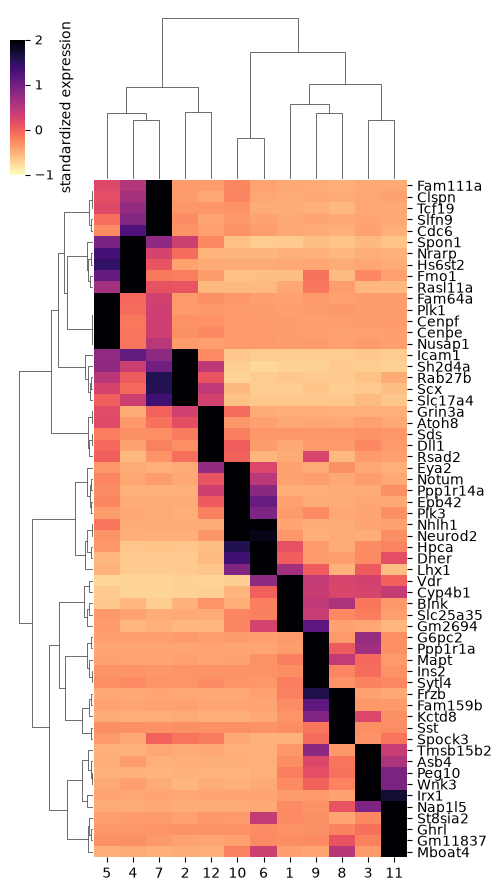

In [24]:
ds.plots.marker_heatmap(
    marker=marker_ref,
    topn=5,
    figsize=(5, 9),
)

In [25]:
markers_csv = "scarf_datasets/pancreas_cluster_markers.csv"
ds.export_markers_to_csv(
    marker=marker_ref,
    csv_filename=markers_csv,
    min_score=0.1,
    min_frac_exp=0.1,
)
pd.read_csv(markers_csv).iloc[:5, :6]

,1,10,11,12,2,3
0,Blnk,Notum,Gm11837,Atoh8,Scx,Irx1
1,Gm2694,Eya2,Mboat4,Dll1,Slc17a4,Tmsb15b2
2,Cyp4b1,Epb42,Ghrl,Grin3a,Rab27b,Asb4
3,Slc25a35,Ppp1r14a,Nap1l5,Sds,Icam1,Peg10
4,Vdr,Plk3,St8sia2,Rsad2,Sh2d4a,Wnk3
